In [1]:
# !pip install --upgrade pip
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn

## Importações de Bibliotecas

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

## Renomear Colunas — `rename()`

In [3]:
df = pd.DataFrame({
    'Nome Completo': ['Ana Silva', 'Bruno Costa', 'Carlos Lima', 'Diana Melo'],
    'Idade (anos)':  [25, 30, 35, 28],
    'Salario R$':    [3000, 4500, 5200, 3800],
    'CIDADE':        ['SP', 'RJ', 'MG', 'SP']
})

df

,Nome Completo,Idade (anos),Salario R$,CIDADE
0,Ana Silva,25,3000,SP
1,Bruno Costa,30,4500,RJ
2,Carlos Lima,35,5200,MG
3,Diana Melo,28,3800,SP


In [4]:
df.columns.tolist()

['Nome Completo', 'Idade (anos)', 'Salario R$', 'CIDADE']

#### Método 1 — `rename()`: renomear colunas específicas

In [5]:
df1 = df.rename(columns={
    'Nome Completo': 'nome',
    'Salario R$':    'salario'
})

df1.columns.tolist()

['nome', 'Idade (anos)', 'salario', 'CIDADE']

#### Método 2 — substituir todas as colunas de uma vez

In [7]:
df2 = df.copy()
df2.columns = ['nome', 'idade', 'salario', 'cidade']

df2.columns.tolist()
df2.head()

,nome,idade,salario,cidade
0,Ana Silva,25,3000,SP
1,Bruno Costa,30,4500,RJ
2,Carlos Lima,35,5200,MG
3,Diana Melo,28,3800,SP


#### Método 3 — padronizar com função `str` (ideal após leitura de CSV)

In [8]:
df3 = df.copy()

df3.columns = (
    df3.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

df3.columns.tolist()

['nome_completo', 'idade_anos', 'salario_r', 'cidade']

In [9]:
df3

,nome_completo,idade_anos,salario_r,cidade
0,Ana Silva,25,3000,SP
1,Bruno Costa,30,4500,RJ
2,Carlos Lima,35,5200,MG
3,Diana Melo,28,3800,SP


## Remover Duplicatas — `drop_duplicates()`

In [10]:
df = pd.DataFrame({
    'nome':   ['Ana', 'Bruno', 'Ana', 'Carlos', 'Bruno', 'Ana'],
    'cidade': ['SP',  'RJ',   'SP',  'MG',     'RJ',    'SP'],
    'compra': [150,    200,   150,    320,      200,     180]
})

df

,nome,cidade,compra
0,Ana,SP,150
1,Bruno,RJ,200
2,Ana,SP,150
3,Carlos,MG,320
4,Bruno,RJ,200
5,Ana,SP,180


#### Diagnosticar duplicatas antes de remover

In [11]:
print(f'Total de linhas: {len(df)}')
print(f'Duplicatas encontradas: {df.duplicated().sum()}')

Total de linhas: 6
Duplicatas encontradas: 2


In [12]:
# Visualizar apenas as linhas duplicadas
df[df.duplicated(keep=False)]

,nome,cidade,compra
0,Ana,SP,150
1,Bruno,RJ,200
2,Ana,SP,150
4,Bruno,RJ,200


#### Remover duplicatas — todas as colunas

In [13]:
df_sem_dup = df.drop_duplicates()

print(f'Linhas restantes: {len(df_sem_dup)}')
df_sem_dup

Linhas restantes: 4


,nome,cidade,compra
0,Ana,SP,150
1,Bruno,RJ,200
3,Carlos,MG,320
5,Ana,SP,180


#### Remover duplicatas por colunas específicas — parâmetro `subset`

In [14]:
# Considera duplicata quem tiver mesmo nome E cidade — mantém a primeira ocorrência
df.drop_duplicates(subset=['nome', 'cidade'], keep='first')

,nome,cidade,compra
0,Ana,SP,150
1,Bruno,RJ,200
3,Carlos,MG,320


In [15]:
# Mantendo a última ocorrência
df.drop_duplicates(subset=['nome', 'cidade'], keep='last')

,nome,cidade,compra
3,Carlos,MG,320
4,Bruno,RJ,200
5,Ana,SP,180


In [16]:
# keep=False — remove TODAS as ocorrências duplicadas
df.drop_duplicates(keep=False)

,nome,cidade,compra
3,Carlos,MG,320
5,Ana,SP,180


---
## Converter Tipos — `astype()`

In [17]:
# Simulando leitura de CSV — colunas com tipos incorretos
df = pd.DataFrame({
    'nome':    ['Ana', 'Bruno', 'Carlos', 'Diana'],
    'idade':   ['25', '30', '35', '28'],           # deveria ser int
    'salario': [3000.0, 4500.0, 5200.0, 3800.0],   # deveria ser int
    'cidade':  ['SP', 'RJ', 'MG', 'SP']            # ideal: category
})

print(df.dtypes)

nome           str
idade          str
salario    float64
cidade         str
dtype: object


In [18]:
print(f'Memória antes: {df.memory_usage(deep=True).sum()} bytes')

Memória antes: 787 bytes


#### `object` → `int`

In [19]:
df['idade'] = df['idade'].astype(int)

print(df['idade'].dtype)
df['idade']

int64


0    25
1    30
2    35
3    28
Name: idade, dtype: int64

#### `float` → `int`

In [20]:
df['salario'] = df['salario'].astype(int)

print(df['salario'].dtype)
df['salario']

int64


0    3000
1    4500
2    5200
3    3800
Name: salario, dtype: int64

#### `object` → `category`

In [21]:
df['cidade'] = df['cidade'].astype('category')

print(f'Categorias únicas: {df["cidade"].cat.categories.tolist()}')
print(f'Códigos internos:  {df["cidade"].cat.codes.tolist()}')

Categorias únicas: ['MG', 'RJ', 'SP']
Códigos internos:  [2, 1, 0, 2]


In [22]:
print(df.dtypes)
print(f'\nMemória depois: {df.memory_usage(deep=True).sum()} bytes')

nome            str
idade         int64
salario       int64
cidade     category
dtype: object

Memória depois: 568 bytes


#### Tratando valores inválidos — `pd.to_numeric()` com `errors='coerce'`

In [23]:
serie = pd.Series(['25', '30', 'N/A', '28', 'desconhecido'])

# errors='coerce' transforma inválidos em NaN em vez de quebrar
pd.to_numeric(serie, errors='coerce')

0    25.0
1    30.0
2     NaN
3    28.0
4     NaN
dtype: float64

In [24]:
# Int64 (I maiúsculo) — nullable integer: aceita NaN e mantém tipo inteiro
pd.to_numeric(serie, errors='coerce').astype('Int64')

0      25
1      30
2    <NA>
3      28
4    <NA>
dtype: Int64

In [25]:
# Converter múltiplas colunas de uma vez
df2 = pd.DataFrame({
    'idade':   ['25', '30', '35'],
    'salario': [3000.0, 4500.0, 5200.0],
    'uf':      ['SP', 'RJ', 'MG']
})

df2 = df2.astype({'idade': int, 'salario': int, 'uf': 'category'})
print(df2.dtypes)

idade         int64
salario       int64
uf         category
dtype: object


---
## Trabalhar com Datas — `pd.to_datetime()` e acessor `.dt`

In [26]:
df = pd.DataFrame({
    'cliente':     ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'data_compra': ['2024-01-15', '2024-03-22', '2024-07-08',
                    '2023-11-30', '2024-09-01'],
    'valor':       [350, 120, 890, 450, 230]
})

print(df.dtypes)
df

cliente          str
data_compra      str
valor          int64
dtype: object


,cliente,data_compra,valor
0,Ana,2024-01-15,350
1,Bruno,2024-03-22,120
2,Carlos,2024-07-08,890
3,Diana,2023-11-30,450
4,Eduardo,2024-09-01,230


#### Converter string → datetime

In [27]:
df['data_compra'] = pd.to_datetime(df['data_compra'])

print(df['data_compra'].dtype)

datetime64[us]


#### Formato brasileiro — `dd/mm/aaaa`

In [28]:
datas_br = pd.Series(['15/01/2024', '22/03/2024', '08/07/2024'])
pd.to_datetime(datas_br, format='%d/%m/%Y')

0   2024-01-15
1   2024-03-22
2   2024-07-08
dtype: datetime64[us]

#### Extrair componentes com o acessor `.dt`

In [29]:
df['ano']        = df['data_compra'].dt.year
df['mes']        = df['data_compra'].dt.month
df['dia']        = df['data_compra'].dt.day
df['dia_semana'] = df['data_compra'].dt.day_name()
df['trimestre']  = df['data_compra'].dt.quarter
df['semana_iso'] = df['data_compra'].dt.isocalendar().week

df[['cliente', 'data_compra', 'ano', 'mes', 'dia', 'dia_semana', 'trimestre', 'semana_iso']]

,cliente,data_compra,ano,mes,dia,dia_semana,trimestre,semana_iso
0,Ana,2024-01-15,2024,1,15,Monday,1,3
1,Bruno,2024-03-22,2024,3,22,Friday,1,12
2,Carlos,2024-07-08,2024,7,8,Monday,3,28
3,Diana,2023-11-30,2023,11,30,Thursday,4,48
4,Eduardo,2024-09-01,2024,9,1,Sunday,3,35


#### Filtrar por período

In [30]:
# Somente compras de 2024
df[df['data_compra'].dt.year == 2024][['cliente', 'data_compra', 'valor']]

,cliente,data_compra,valor
0,Ana,2024-01-15,350
1,Bruno,2024-03-22,120
2,Carlos,2024-07-08,890
4,Eduardo,2024-09-01,230


In [31]:
# Primeiro semestre de 2024
mask = (df['data_compra'] >= '2024-01-01') & (df['data_compra'] <= '2024-06-30')
df[mask][['cliente', 'data_compra', 'valor']]

,cliente,data_compra,valor
0,Ana,2024-01-15,350
1,Bruno,2024-03-22,120


#### Tratamento de datas inválidas — `errors='coerce'` e `NaT`

In [32]:
serie = pd.Series(['2024-01-15', 'data inválida', '2024-07-08', 'N/A'])
convertida = pd.to_datetime(serie, errors='coerce')

print(convertida)
print(f'\nQuantidade de NaT: {convertida.isna().sum()}')

0   2024-01-15
1          NaT
2   2024-07-08
3          NaT
dtype: datetime64[us]

Quantidade de NaT: 2


#### Diferença entre datas

In [33]:
df_prazos = pd.DataFrame({
    'pedido':       ['P001', 'P002', 'P003'],
    'data_pedido':  ['2024-01-10', '2024-02-05', '2024-03-20'],
    'data_entrega': ['2024-01-18', '2024-02-12', '2024-04-02']
})

df_prazos['data_pedido']  = pd.to_datetime(df_prazos['data_pedido'])
df_prazos['data_entrega'] = pd.to_datetime(df_prazos['data_entrega'])
df_prazos['prazo_dias']   = (df_prazos['data_entrega'] - df_prazos['data_pedido']).dt.days

df_prazos

,pedido,data_pedido,data_entrega,prazo_dias
0,P001,2024-01-10,2024-01-18,8
1,P002,2024-02-05,2024-02-12,7
2,P003,2024-03-20,2024-04-02,13


---
## Correlação de Pearson — `df.corr()` e `sns.heatmap()`

A correlação de Pearson mede a **força e a direção** da relação linear entre duas variáveis numéricas.

| Valor de r | Interpretação |
|---|---|
| ±1,0 | Correlação linear perfeita |
| \|r\| > 0,7 | Forte |
| 0,3 < \|r\| < 0,7 | Moderada |
| \|r\| < 0,3 | Fraca |
| 0 | Sem correlação linear |

> ⚠️ **Correlação ≠ causalidade.** Use apenas com variáveis numéricas contínuas e relação esperada linear.

In [34]:
df = pd.DataFrame({
    'idade':      [22, 35, 41, 28, 55, 30, 47, 38, 26, 52],
    'salario':    [2800, 4500, 5200, 3100, 7000, 3800, 6100, 4900, 2600, 6800],
    'filhos':     [0, 1, 2, 0, 3, 1, 2, 1, 0, 3],
    'distancia':  [10, 25, 30, 8, 45, 15, 38, 22, 5, 42],
    'satisfacao': [8, 7, 6, 9, 5, 8, 6, 7, 9, 4]
})

df

,idade,salario,filhos,distancia,satisfacao
0,22,2800,0,10,8
1,35,4500,1,25,7
2,41,5200,2,30,6
3,28,3100,0,8,9
4,55,7000,3,45,5
5,30,3800,1,15,8
6,47,6100,2,38,6
7,38,4900,1,22,7
8,26,2600,0,5,9
9,52,6800,3,42,4


#### Calcular a matriz de correlação

In [35]:
corr = df.corr(method='pearson')
corr.round(2)

,idade,salario,filhos,distancia,satisfacao
idade,1.00,0.99,0.97,0.97,-0.93
salario,0.99,1.00,0.97,0.99,-0.95
filhos,0.97,0.97,1.00,0.97,-0.96
distancia,0.97,0.99,0.97,1.00,-0.96
satisfacao,-0.93,-0.95,-0.96,-0.96,1.00


#### Correlação entre um par específico de variáveis

In [36]:
r_idade_salario = df['idade'].corr(df['salario'])
r_dist_satisf   = df['distancia'].corr(df['satisfacao'])

print(f'r (idade × salário):        {r_idade_salario:.2f}')
print(f'r (distância × satisfação): {r_dist_satisf:.2f}')

r (idade × salário):        0.99
r (distância × satisfação): -0.96


#### Filtrar pares com correlação forte

In [37]:
threshold = 0.6

pares = (
    corr.abs()
    .stack()
    .reset_index()
    .rename(columns={0: 'r', 'level_0': 'var1', 'level_1': 'var2'})
    .query('var1 < var2 and r >= @threshold')
    .sort_values('r', ascending=False)
)

print(f'Pares com |r| >= {threshold}:')
pares

Pares com |r| >= 0.6:


,var1,var2,r
1,idade,salario,0.989736
16,distancia,salario,0.989430
15,distancia,idade,0.973511
11,filhos,salario,0.972760
17,distancia,filhos,0.970522
10,filhos,idade,0.967076
14,filhos,satisfacao,0.962109
19,distancia,satisfacao,0.961895
9,salario,satisfacao,0.954159
4,idade,satisfacao,0.927691


#### Visualizar com `sns.heatmap()`

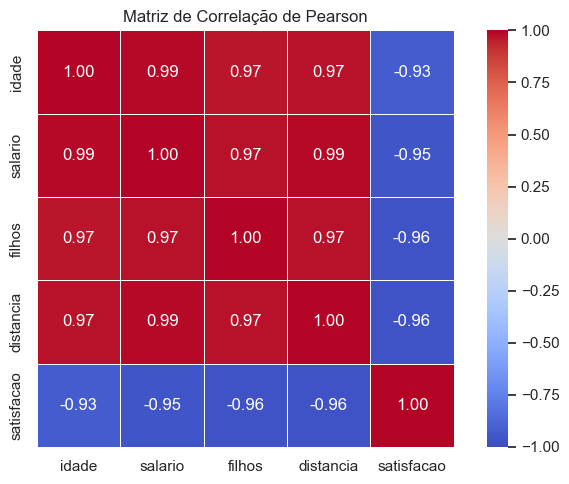

In [38]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white'
)
plt.title('Matriz de Correlação de Pearson')
plt.tight_layout()
plt.show()

#### Scatter plot — par com maior correlação

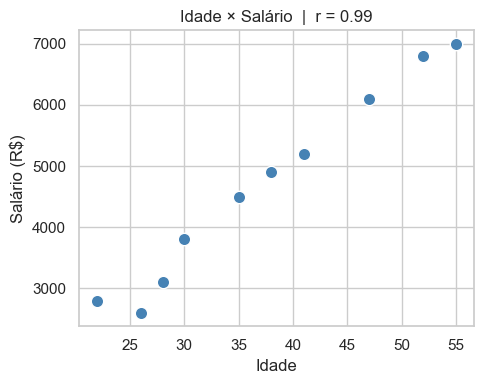

In [39]:
plt.figure(figsize=(5, 4))
plt.scatter(df['idade'], df['salario'], color='steelblue', edgecolors='white', s=80)
plt.xlabel('Idade')
plt.ylabel('Salário (R$)')
plt.title(f'Idade × Salário  |  r = {r_idade_salario:.2f}')
plt.tight_layout()
plt.show()

---
## Resumo Geral

| Operação | Método principal | Observação |
|---|---|---|
| Renomear colunas específicas | `df.rename(columns={...})` | Não altera as demais |
| Padronizar todos os nomes | `df.columns.str.lower()` | Ideal após leitura de CSV |
| Remover duplicatas | `df.drop_duplicates()` | Use `subset` e `keep` |
| Converter tipo | `df[col].astype(tipo)` | Cuidado com NaN |
| Tratar inválidos na conversão | `pd.to_numeric(errors='coerce')` | Gera NaN nos inválidos |
| Converter data | `pd.to_datetime(df[col])` | Use `format=` para datas BR |
| Extrair componentes de data | `df[col].dt.year`, `.dt.month`... | Requer dtype datetime |
| Matriz de correlação | `df.corr(method='pearson')` | Somente colunas numéricas |
| Visualizar correlação | `sns.heatmap(corr, annot=True)` | `cmap='coolwarm'` é padrão |